*Planned detection/algorithm flow*

**For point anomalies:**
telemetry data (only the first column) -> IQR -> analyze results

**For contextual anomalies**
telemetry data with all the features -> k-NN and LOF -> analyze results


First import dataset from kaggle

In [121]:
import os
import zipfile
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from sklearn.neighbors import LocalOutlierFactor, NearestNeighbors
from sklearn.ensemble import IsolationForest
import time

from dotenv import load_dotenv

load_dotenv()  # load .env variables into the session

True

In [2]:
kaggle_username = os.getenv("KAGGLE_USERNAME")
kaggle_key = os.getenv("KAGGLE_KEY")

In [ ]:
os.system("kaggle datasets download patrickfleith/nasa-anomaly-detection-dataset-smap-msl") # downloaded as zip file

Dataset URL: https://www.kaggle.com/datasets/patrickfleith/nasa-anomaly-detection-dataset-smap-msl
License(s): copyright-authors


 96%|█████████▋| 79.0M/82.0M [00:05<00:00, 19.9MB/s]

100%|██████████| 82.0M/82.0M [00:05<00:00, 15.7MB/s]


0

In [ ]:
with zipfile.ZipFile("nasa-anomaly-detection-dataset-smap-msl.zip", "r") as zip_ref:
    zip_ref.extractall("./data")

In [122]:
p_1 = np.load("data/data/data/test/E-13.npy")

print(p_1.shape)

m_6 = np.load("data/data/data/test/M-6.npy")

print(m_6[:, 0])

(8640, 25)
[ -1.          -1.          -1.         ... 129.89189189 129.89189189
 129.89189189]


Get channels that belong to MSL measures and SMAP measures

In [123]:
labeled_data = pd.read_csv("data/labeled_anomalies.csv")
chan_and_spacecraft =  labeled_data[["chan_id" , "spacecraft"]]

msl_data = chan_and_spacecraft[chan_and_spacecraft["spacecraft"] == "MSL"]
smap_data = chan_and_spacecraft[chan_and_spacecraft["spacecraft"] == "SMAP"]

msl_channels = msl_data["chan_id"].to_list()
smap_channels = smap_data["chan_id"].to_list()

print(smap_channels)
print(msl_channels)

['P-1', 'S-1', 'E-1', 'E-2', 'E-3', 'E-4', 'E-5', 'E-6', 'E-7', 'E-8', 'E-9', 'E-10', 'E-11', 'E-12', 'E-13', 'A-1', 'D-1', 'P-2', 'P-3', 'D-2', 'D-3', 'D-4', 'A-2', 'A-3', 'A-4', 'G-1', 'G-2', 'D-5', 'D-6', 'D-7', 'F-1', 'P-4', 'G-3', 'T-1', 'T-2', 'D-8', 'D-9', 'F-2', 'G-4', 'T-3', 'D-11', 'D-12', 'B-1', 'G-6', 'G-7', 'P-7', 'R-1', 'A-5', 'A-6', 'A-7', 'D-13', 'P-2', 'A-8', 'A-9', 'F-3']
['M-6', 'M-1', 'M-2', 'S-2', 'P-10', 'T-4', 'T-5', 'F-7', 'M-3', 'M-4', 'M-5', 'P-15', 'C-1', 'C-2', 'T-12', 'T-13', 'F-4', 'F-5', 'D-14', 'T-9', 'P-14', 'T-8', 'P-11', 'D-15', 'D-16', 'M-7', 'F-8']


There are multiple channel measurements for the spacecrafts. We need to check the shapes of the data.

In [124]:
def check_shape_and_attribute_numbers(spacecraft_channels, exp_attr_num):
    for channel in spacecraft_channels:
        dir = f"data/data/data/test/{channel}.npy"
        raw_data = np.load(dir)

        if raw_data.shape[1] != exp_attr_num: 
            print("Inconsistent attribute numbers.")
            return

    print("Consistent attribute number.")
        

#### The number of attributes across different channels of the same spacecraft are consistent.

55 attributes for MSL and 25 attributes for SMAP

In [125]:
# check the shape of each channel and attribute numbers
check_shape_and_attribute_numbers(smap_channels, 25) 
check_shape_and_attribute_numbers(msl_channels, 55)


Consistent attribute number.
Consistent attribute number.


Point anomalies are single values that fall within low-density regions of values, collective anomalies indicate that a sequence of values is anomalous 
rather than any single value by itself, and contextual anomalies are single values that do not fall within low-density regions yet are anomalous with 
regard to local values. (Hundman et al)


In this study i will explor point and contextual anomalies

In [126]:
import re

def parse_class(class_str):
    # list return ediyor, stringden ayrıştırıyoruz
    return re.findall(r'point|contextual', class_str)

labeled_data['class_parsed'] = labeled_data['class'].apply(parse_class)

# check if worked
print(labeled_data['class_parsed'].head())

0    [contextual, contextual, contextual]
1                                 [point]
2                [contextual, contextual]
3                                 [point]
4                                 [point]
Name: class_parsed, dtype: object


Rows with mixed anomalies will be out of scope because this study uses explicitly different methods for point anomaly and contextual anomaly detections.

In [127]:
# extract data that only has "point" or "contextual" anomalies
# this way we exclude any data point that has mixed anomalies - data pruning
point_channels = labeled_data[labeled_data['class_parsed'].apply(lambda x: all(c == 'point' for c in x))]['chan_id'].tolist()
contextual_channels = labeled_data[labeled_data['class_parsed'].apply(lambda x: all(c == 'contextual' for c in x))]['chan_id'].tolist()

print(f"Point channels: {point_channels}")
print(f"Contextual channels: {contextual_channels}")

Point channels: ['S-1', 'E-2', 'E-3', 'E-4', 'E-5', 'E-6', 'E-7', 'E-8', 'E-9', 'A-1', 'D-1', 'P-2', 'P-3', 'D-2', 'D-3', 'D-4', 'G-2', 'D-5', 'D-6', 'D-7', 'F-1', 'P-4', 'G-3', 'T-2', 'D-8', 'D-9', 'F-2', 'G-4', 'T-3', 'D-11', 'D-12', 'B-1', 'G-6', 'R-1', 'A-5', 'A-6', 'D-13', 'P-2', 'M-6', 'S-2', 'P-10', 'T-4', 'T-5', 'P-15', 'F-4', 'F-5', 'D-14', 'T-9', 'P-14', 'P-11', 'D-15', 'M-7']
Contextual channels: ['P-1', 'E-1', 'E-10', 'E-11', 'E-12', 'E-13', 'A-2', 'A-3', 'A-4', 'G-1', 'P-7', 'A-7', 'A-8', 'A-9', 'F-3', 'M-1', 'M-2', 'F-7', 'M-3', 'M-4', 'M-5', 'T-12', 'T-13', 'T-8', 'D-16', 'F-8']


In [128]:
def parse_anomaly_sequences(sequence_str):
    # find all pairs of numbers in the string
    pairs = re.findall(r'\[(\d+),\s*(\d+)\]', sequence_str)
    # convert to list of [int, int]
    return [[int(start), int(end)] for start, end in pairs]

labeled_data['anomaly_sequences_parsed'] = labeled_data['anomaly_sequences'].apply(parse_anomaly_sequences)
print(labeled_data['anomaly_sequences_parsed'].head())

0    [[2149, 2349], [4536, 4844], [3539, 3779]]
1                                [[5300, 5747]]
2                  [[5000, 5030], [5610, 6086]]
3                                [[5598, 6995]]
4                                [[5094, 8306]]
Name: anomaly_sequences_parsed, dtype: object


We will visualize the data. 

Based on the num_values attribute in the labeled_anomalies.csv file, it is found out that the data in the /data/test directory are the full-length telemetry data, where /data/train directory are only parts that are seperated for training for deep-learning-based approaches.

In [ ]:
# visualize the data using the labeled csv file to understand the anomalies and the nature of measurements.
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd

def plot_spacecraft_channels(spacecraft_channels, spacecraft_name, labeled_data):
    """
    Plots the sensor reading (column 0) for each channel of a spacecraft.
    Highlights anomalous regions in red using ground truth labels.
    """
    n_channels = len(spacecraft_channels)
    fig, axes = plt.subplots(n_channels, 1, figsize=(15, n_channels * 2))
    fig.suptitle(f"{spacecraft_name} — Sensor Readings Across All Channels", 
                 fontsize=14, fontweight='bold', y=1.01)
    
    for i, channel in enumerate(spacecraft_channels):
        # Load test data (anomalies are in test set)
        dir = f"data/data/data/test/{channel}.npy"
        raw_data = np.load(dir)
        sensor_reading = raw_data[:, 0]  # column 1 — the behavioral attribute
        
        ax = axes[i] if n_channels > 1 else axes
        
        # Plot sensor reading
        ax.plot(sensor_reading, color='steelblue', linewidth=0.8, label='Sensor Reading')
        
        # Highlight anomaly regions from labels
        channel_label = labeled_data[labeled_data['chan_id'] == channel]
        if not channel_label.empty:
            anomaly_sequences = eval(channel_label['anomaly_sequences'].values[0])
            for seq in anomaly_sequences:
                ax.axvspan(seq[0], seq[1], alpha=0.3, color='red', label='Anomaly')
        
        ax.set_ylabel(channel, fontsize=8, rotation=0, labelpad=40)
        ax.set_xlim(0, len(sensor_reading))
        ax.tick_params(axis='both', labelsize=7)
        ax.grid(True, alpha=0.3)
    
    # Add legend once
    normal_patch = mpatches.Patch(color='steelblue', label='Normal')
    anomaly_patch = mpatches.Patch(color='red', alpha=0.3, label='Anomaly')
    fig.legend(handles=[normal_patch, anomaly_patch], 
               loc='upper right', fontsize=10)
    
    plt.tight_layout()
    plt.savefig(f"{spacecraft_name}_channels_overview.png", 
                dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Plot saved as {spacecraft_name}_channels_overview.png")


# Plot all SMAP channels
plot_spacecraft_channels(smap_channels, "SMAP", labeled_data)

# Plot all MSL channels
plot_spacecraft_channels(msl_channels, "MSL", labeled_data)

In [49]:
def plot_channel_reading(chan: str, title: str):
    
    dir = f"data/data/data/test/{chan}.npy"
    raw_data = np.load(dir)
    sensor_reading = raw_data[:, 0] # get the sensor reading

    plt.xlabel("Data point")
    plt.ylabel("Mesaured Telemetry Data")
    plt.title(title)
    
    # Plot sensor reading
    plt.plot(sensor_reading, color='steelblue', linewidth=0.8, label='Sensor Reading', )

All the plots for SMAP and MSL data can be found in SMAP_channels_overview.png and MSL_channels_overview.png

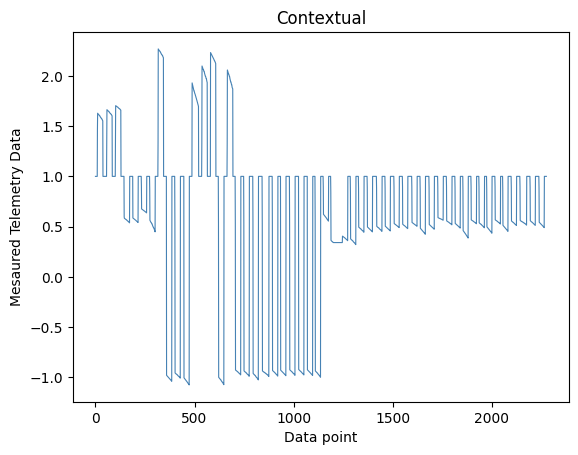

In [129]:
# Quick visualization for one point and one contextual anomaly channel.
plot_channel_reading("M-1", "Contextual")

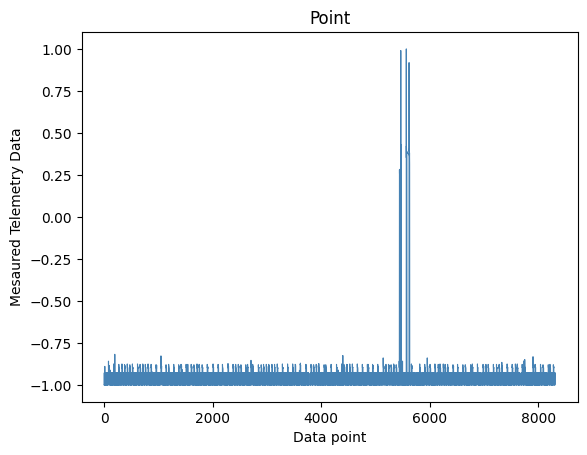

In [130]:
plot_channel_reading("E-7", "Point")

### 1. POINT ANOMALIES

Below, we define the methods that will be used to detect the point anomalies.
Some of these methods/functions, like k-NN, will also be used during the contextual anomaly detection section.

In [131]:
# IQR calculation

# tek channel datası verilecek parametre olarak.
def IQR_calculator(data) -> tuple:
    # 2- get the %25 and %75 of data IQR ranges
    # 3- calculate IQR

    data = data[:, 0]
    Q1 = np.percentile(data, 25)
    Q3 = np.percentile(data, 75)

    IQR = Q3-Q1

    lower_bound = Q1 - 1.5*IQR
    higher_bound = Q3 + 1.5*IQR

    scores = np.maximum(lower_bound - data, 0) + np.maximum(data - higher_bound, 0)
    predicted_labels = (scores > 0).astype(int)
    
    """outliers = [] 

        for i in data:
            if i < lower_bound or i > higher_bound:
                outliers.append(i)

        return outliers"""
    #print(lower_bound, higher_bound)
    #print(sorted_data)

    results_df = pd.DataFrame({
        'timestep': np.arange(len(data)),
        'sensor_value': data,
        'anomaly_score': scores,
        'is_outlier': predicted_labels
    })

    outlier_timesteps = np.where(predicted_labels == 1)[0]

    return results_df, outlier_timesteps

   


In [132]:
e_7 = np.load("data/data/data/test/E-7.npy")

results, timesteps = IQR_calculator(e_7)

print(len(timesteps))
# how many outliers found
print(results[results['is_outlier'] == 1]['timestep'].tolist())

40
[195, 5440, 5441, 5442, 5443, 5444, 5445, 5465, 5466, 5467, 5468, 5469, 5470, 5471, 5472, 5473, 5474, 5475, 5567, 5568, 5569, 5570, 5571, 5572, 5573, 5574, 5575, 5576, 5577, 5618, 5619, 5620, 5621, 5622, 5623, 5624, 5625, 5626, 5627, 5628]
